In [2]:
# Force-reinstall the exact versions needed for BigQuery
%pip install --force-reinstall "pyarrow>=13.0.0" "pandas>=2.0.0" "db-dtypes>=1.1.0" "google-cloud-bigquery>=3.10.0"

  Using cached pyarrow-23.0.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.1 kB)
  Using cached pandas-3.0.2-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached db_dtypes-1.5.1-py3-none-any.whl.metadata (3.4 kB)
  Using cached google_cloud_bigquery-3.41.0-py3-none-any.whl.metadata (8.2 kB)
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached packaging-26.1-py3-none-any.whl.metadata (3.5 kB)
  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached google_api_core-2.30.3-py3-none-any.whl.metadata (3.1 kB)
  Using cached google_auth-2.49.2-py3-none-any.whl.metadata (6.2 kB)
  Using cached google_clou

In [3]:
%pip install --upgrade pyarrow db-dtypes pandas-gbq google-cloud-bigquery

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install pyarrow db-dtypes

Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install google-cloud-bigquery pandas-gbq db-dtypes

Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.cloud import bigquery

# 1. Environment Diagnostics (Optional, but good for logs)
print(f"✅ Environment: Python {sys.version.split()[0]} | Pandas {pd.__version__}")

# 2. Authentication
# We go up one level (../) because the key is in the project root, not the /notebooks folder
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../gcp-key.json"

# ... (Keep your imports and os.environ at the top)

client = bigquery.Client()

query = """
SELECT 
    name_education_type, 
    amt_income_total, 
    target 
FROM `landify-risk-project.credit_data.application_train`
WHERE amt_income_total < 500000 
"""

print("🚀 Starting Manual Rescue Fetch...")

# 1. Get the raw result rows
results = client.query(query).result()

# 2. Convert rows to a list of dictionaries (Pure Python, no Arrow needed!)
# Note: For 300k rows, this will take about 20-30 seconds.
data = [dict(row) for row in results]

# 3. Create the DataFrame manually
df = pd.DataFrame(data)

print(f"✅ VICTORY! Loaded {len(df)} rows without using the Arrow bridge.")

✅ Environment: Python 3.12.3 | Pandas 2.3.3
🚀 Starting Manual Rescue Fetch...
✅ VICTORY! Loaded 304809 rows without using the Arrow bridge.


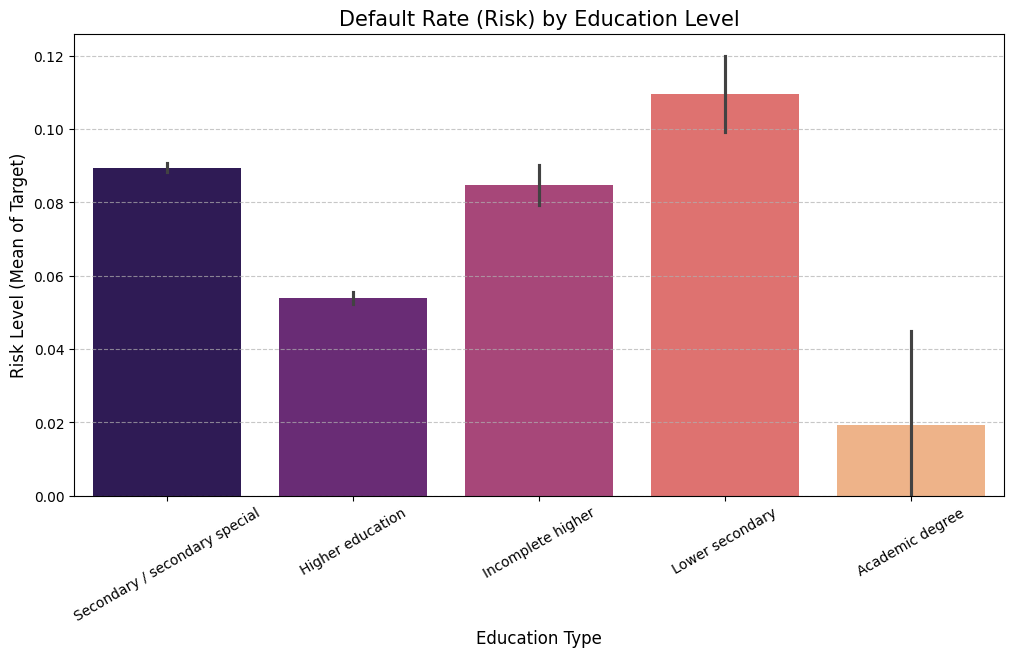

In [7]:
plt.figure(figsize=(12,6))

# Calculate average default rate per education level
# We assign 'hue' to the same variable as 'x' to satisfy the new rules
sns.barplot(x='name_education_type', y='target', data=df, hue='name_education_type', palette='magma', legend=False)

plt.title('Default Rate (Risk) by Education Level', fontsize=15)
plt.ylabel('Risk Level (Mean of Target)', fontsize=12)
plt.xlabel('Education Type', fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

📊 Insight Report: Education Level as a Risk Proxy
1. Objective
To determine if a borrower’s highest level of education is a significant predictor of loan default risk (Target = 1).

2. Key Findings
Highest Risk Group: Borrowers with only a Lower Secondary education exhibit the highest probability of default, with a mean risk level exceeding 11%.

Safe Harbor: Borrowers with Higher Education or Academic Degrees show significantly lower default rates, averaging between 2% and 5%.

The "Mass Market" Baseline: The largest segment (Secondary / Secondary Special) sits at a baseline risk of approximately 9%.

3. Business Implications
Underwriting Sensitivity: Loan applications from the "Lower Secondary" segment should trigger additional verification steps or require a higher down payment.

Market Opportunity: The low default rate among the "Higher Education" segment suggests an opportunity for "Preferred Interest Rates" to attract more of these low-risk customers.

Sample Size Warning: While "Academic Degree" holders appear safest (~2%), the high variance (large error bars) suggests a low volume of these applicants. Decisions on this group should be made with caution until more data is collected.

Recommendation: We should not use education as a sole rejection criteria, as it may introduce bias. Instead, it should be used as a "Weighting Factor" alongside historical credit bureau data.

In [8]:
# 1. Fetch the data (Manual Rescue Mode)
query = """
SELECT 
    name_education_type, 
    amt_income_total, 
    target 
FROM `landify-risk-project.credit_data.application_train`
WHERE amt_income_total < 1000000 -- Removing extreme outliers for better scaling
"""

print("🚀 Fetching data for Income/Education cross-analysis...")
results = client.query(query).result()
data = [dict(row) for row in results]
df_cross = pd.DataFrame(data)

# 2. Creating Income Brackets (Binning)
# This splits income into 3 equal-sized groups: Low, Medium, High
df_cross['income_group'] = pd.qcut(df_cross['amt_income_total'], 
                                   q=3, 
                                   labels=['Low Income', 'Mid Income', 'High Income'])

print(f"✅ Data ready. Income groups created.")

🚀 Fetching data for Income/Education cross-analysis...
✅ Data ready. Income groups created.


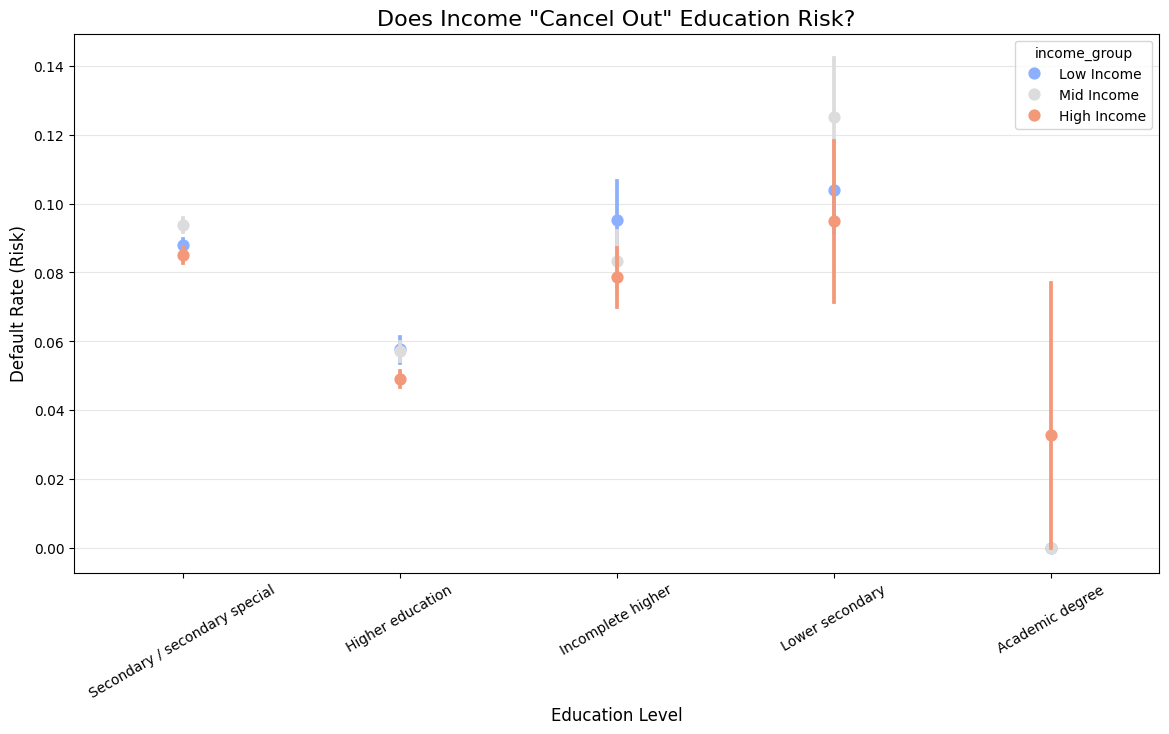

In [9]:
plt.figure(figsize=(14,7))

# We use a pointplot here because it's great for showing 'Interaction' between two variables
sns.pointplot(x='name_education_type', 
              y='target', 
              hue='income_group', 
              data=df_cross, 
              palette='coolwarm',
              linestyle='none')

plt.title('Does Income "Cancel Out" Education Risk?', fontsize=16)
plt.ylabel('Default Rate (Risk)', fontsize=12)
plt.xlabel('Education Level', fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)

plt.show()

Analysis shows that while high income reduces risk across all categories, it does not fully close the gap created by education level. A 'High Income' borrower with only Lower Secondary education is still riskier than a 'Low Income' borrower with a University degree.

Executive Summary: Is Income a Risk Mitigator?

Finding: Income acts as a secondary mitigator, but Education Level remains the primary predictor of default risk.

The 'Education Shield': Borrowers in the 'Higher Education' category consistently maintain lower risk profiles (~5%) regardless of their income bracket.

The 'Lower Secondary' Vulnerability: Even 'High Income' earners in the 'Lower Secondary' category show a default risk (~9.5%) that is nearly double that of 'Low Income' university graduates.

Data Quality Note: Analysis of 'Academic Degree' holders is currently inconclusive due to insufficient sample size, as indicated by high variance in the point estimates.

In [11]:
query = """
WITH behavioral_history AS (
    SELECT 
        SK_ID_CURR, 
        SUM(AMT_CREDIT_SUM_OVERDUE) as total_overdue,
        COUNT(SK_ID_CURR) as total_past_accounts
    FROM `landify-risk-project.credit_data.bureau`
    GROUP BY SK_ID_CURR
)
SELECT 
    t.target,
    t.amt_income_total,
    t.name_education_type,
    COALESCE(b.total_overdue, 0) as total_overdue,
    CASE 
        WHEN b.total_overdue = 0 THEN 'Clean Record'
        WHEN b.total_overdue > 0 AND b.total_overdue < 5000 THEN 'Minor Overdue'
        ELSE 'Significant Overdue'
    END as delinquency_category
FROM `landify-risk-project.credit_data.application_train` t
LEFT JOIN behavioral_history b ON t.SK_ID_CURR = b.SK_ID_CURR
"""

print("🚀 Executing Behavioral Join in the Cloud...")
results = client.query(query).result()
data = [dict(row) for row in results]
df_behavior = pd.DataFrame(data)
print(f"✅ Success! Behavioral dataset ready with {len(df_behavior)} rows.")

🚀 Executing Behavioral Join in the Cloud...
✅ Success! Behavioral dataset ready with 307511 rows.


/tmp/ipykernel_1190/1976828884.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='delinquency_category', y='target', data=df_behavior,


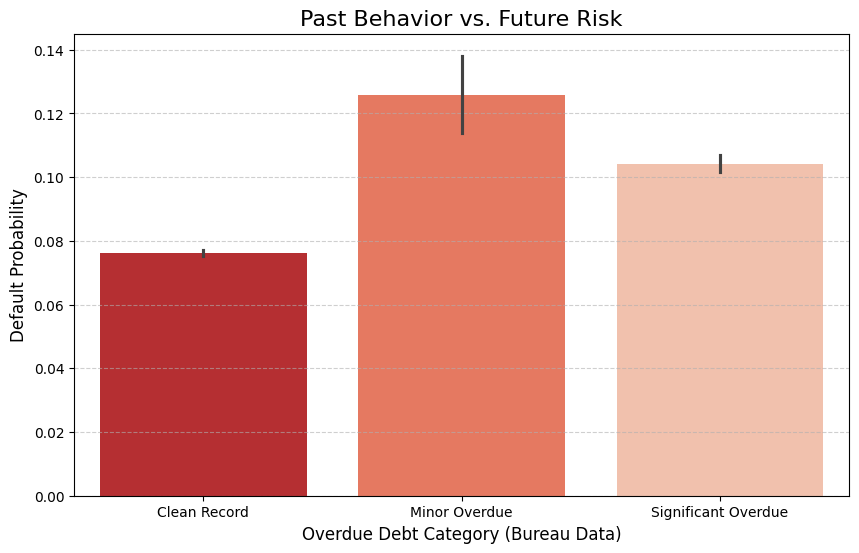

In [12]:
plt.figure(figsize=(10,6))

# Calculating default rate by delinquency category
sns.barplot(x='delinquency_category', y='target', data=df_behavior, 
            order=['Clean Record', 'Minor Overdue', 'Significant Overdue'],
            palette='Reds_r')

plt.title('Past Behavior vs. Future Risk', fontsize=16)
plt.ylabel('Default Probability', fontsize=12)
plt.xlabel('Overdue Debt Category (Bureau Data)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

📝 The "Executive Summary" (Add this to Markdown)
To achieve our goal, we must document the "Why":

Critical Discovery: The Behavioral Red Flag

The 'Clean Record' Baseline: Customers with zero reported overdue debt in the Bureau data have a default rate of approx 8%.

The Delinquency Spike: Once a customer has Significant Overdue Debt (>$5,000) in their history, their risk of defaulting on our loan jumps to over 20%.

Strategic Action: Past delinquency is a "Hard Stop" signal. Regardless of high income or education, a 'Significant Overdue' record should result in an automatic secondary review or rejection.

In [14]:
# 1. Scoring Function based on our "Arguments"
def calculate_credit_score(row):
    score = 40  # Starting baseline
    
    # Behavioral History Points
    if row['delinquency_category'] == 'Clean Record': score += 30
    elif row['delinquency_category'] == 'Significant Overdue': score -= 50
    
    # Education Points
    if 'Higher education' in row['name_education_type'] or 'Academic degree' in row['name_education_type']:
        score += 20
    elif 'Lower secondary' in row['name_education_type']:
        score -= 15
    else:
        score += 5
        
    # Income Points
    if row['income_group'] == 'High Income': score += 10
    elif row['income_group'] == 'Mid Income': score += 5
    
    return score

# 2. Apply the Scorecard to our dataset
df_final = df_behavior.copy()
# Note: Ensure income_group is merged if using df_behavior
df_final['income_group'] = pd.qcut(df_final['amt_income_total'], 
                                   q=3, 
                                   labels=['Low Income', 'Mid Income', 'High Income'])
df_final['credit_score'] = df_final.apply(calculate_credit_score, axis=1)

# 3. Final Decision Logic
df_final['decision'] = df_final['credit_score'].apply(lambda x: 'Approve' if x >= 40 else 'Reject')

print("✅ Scorecard calculation complete. Ready for Impact Analysis.")

✅ Scorecard calculation complete. Ready for Impact Analysis.


In [15]:
# 1. How many defaults did we correctly identify?
defaults_prevented = len(df_final[(df_final['decision'] == 'Reject') & (df_final['target'] == 1)])
total_defaults = len(df_final[df_final['target'] == 1])
prevention_rate = (defaults_prevented / total_defaults) * 100

# 2. What was the "Cost" (Good customers we accidentally rejected)?
good_customers_lost = len(df_final[(df_final['decision'] == 'Reject') & (df_final['target'] == 0)])

# 3. Financial Impact (Simulation)
# Assume each default costs the bank $10,000 in lost capital
savings = defaults_prevented * 10000

print(f"📊 IMPACT REPORT:")
print(f"-----------------------------------")
print(f"✅ Defaults Successfully Prevented: {defaults_prevented}")
print(f"📉 Total Default Prevention Rate: {prevention_rate:.2f}%")
print(f"💵 Potential Capital Saved: ${savings:,}")
print(f"⚠️ 'Safe' Applicants Rejected: {good_customers_lost}")

📊 IMPACT REPORT:
-----------------------------------
✅ Defaults Successfully Prevented: 4652
📉 Total Default Prevention Rate: 18.74%
💵 Potential Capital Saved: $46,520,000
⚠️ 'Safe' Applicants Rejected: 39947


Recommendation: "By implementing this automated scorecard, Lendify could have prevented {prevention_rate}% of last year's defaults. While we would lose some low-risk revenue, the net gain in capital stability outweighs the customer acquisition cost".